# ETA Prediction — XGBoost

In [1]:
# ── CELDA 2: MODIFICADA XGBoost — imports ────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb                    # NUEVO: reemplaza RandomForestRegressor

print('Librerías cargadas.')
print(f'XGBoost version: {xgb.__version__}')


Librerías cargadas.
XGBoost version: 3.2.0


In [2]:
# ── CELDA 3: MODIFICADA CON CARGA Y RECORTE CRONOLÓGICO CONTINUO ─────────────
path_csv = "/Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/mta_1706.csv"

print("Cargando dataset...")
# ¡Esta es la línea que faltaba para definir 'df'!
df = pd.read_csv(path_csv, on_bad_lines='skip', low_memory=False)

print("Ordenando cronológicamente...")
# Ahora sí podés ordenar df porque ya fue cargado arriba
df = df.sort_values('RecordedAtTime').reset_index(drop=True)

# Tomamos el bloque continuo de los primeros 3,000,000 de registros
df_sample = df.iloc[:3000000].copy()

print(f"Dataset recortado cronológicamente. Filas seleccionadas: {len(df_sample):,}")

Cargando dataset...
Ordenando cronológicamente...
Dataset recortado cronológicamente. Filas seleccionadas: 3,000,000


In [3]:
# ── CELDA 5: MODIFICADA v3 — más columnas críticas ───────────────────────────
# NUEVO v3: agregamos ScheduledArrivalTime y PublishedLineName

print("Eliminando filas con valores nulos en columnas clave...")
df_processed = df_sample.dropna(subset=[
    'ExpectedArrivalTime',
    'RecordedAtTime',
    'DistanceFromStop',
    'VehicleLocation.Latitude',
    'VehicleLocation.Longitude',
    'VehicleRef',
    'ArrivalProximityText',
    'ScheduledArrivalTime',       # NUEVO v3: para schedule_delay (Liu 2021)
    'PublishedLineName',           # NUEVO v3: para line_enc (AlKheder 2022)
    'DestinationLat',              # NUEVO v3: para dist_to_destination_m
    'DestinationLong',             # NUEVO v3: para dist_to_destination_m
]).copy()

print(f"Filas después de limpiar nulos: {len(df_processed)}")
df_processed.head()


Eliminando filas con valores nulos en columnas clave...
Filas después de limpiar nulos: 2636153


,RecordedAtTime,DirectionRef,PublishedLineName,OriginName,OriginLat,OriginLong,DestinationName,DestinationLat,DestinationLong,VehicleRef,VehicleLocation.Latitude,VehicleLocation.Longitude,NextStopPointName,ArrivalProximityText,DistanceFromStop,ExpectedArrivalTime,ScheduledArrivalTime
1,2017-06-01 00:02:05,0,B15,MARCUS GARVEY BL/BROADWAY,40.699722,-73.941513,JFK AIRPORT,40.646908,-73.779564,NYCT_6817,40.669059,-73.875665,DUMONT AV/FOUNTAIN AV,approaching,147.0,2017-06-01 00:03:56,24:01:52
2,2017-06-01 00:02:29,0,Q2,165 ST/TERMINAL,40.707832,-73.795425,BELMONT PK 225 ST,40.711597,-73.729149,NYCT_8503,40.713117,-73.735867,HEMPSTEAD AV/SPRINGFIELD BL,approaching,67.0,2017-06-01 00:03:56,23:59:14
3,2017-06-01 00:03:13,1,X1,CENTRAL PARK S/6 AV,40.766315,-73.977493,ELTNGVLE TRANST CTR via HYLAN BL RICH AV,40.560837,-74.171120,NYCT_2558,40.610616,-74.032467,NARROWS RD N/FINGERBOARD RD,2.1 miles away,3365.0,2017-06-01 00:06:33,23:57:00
4,2017-06-01 00:03:18,1,Q48,ROOSEVELT AV/MAIN ST,40.759586,-73.830299,LAGUARDIA AIRPORT,40.768642,-73.868271,NYCT_4189,40.758090,-73.861048,108 ST/NORTHERN BL,at stop,9.0,2017-06-01 00:03:56,23:58:08
5,2017-06-01 00:03:20,1,Q56,JAMAICA AV/170 ST,40.707287,-73.789581,BWAY JCT VN SNDRN AV,40.678608,-73.903664,NYCT_4853,40.702378,-73.818499,JAMAICA AV/132 ST,< 1 stop away,195.0,2017-06-01 00:04:19,24:00:56


In [4]:
# ── CELDAS 6-9: FEATURE ENGINEERING BASE ──────────────────────────────────────
print("Creando características base (Tiempos, Distancias estáticas y Delays)...")

df_processed['ExpectedArrivalTime'] = pd.to_datetime(df_processed['ExpectedArrivalTime'])
df_processed['RecordedAtTime']      = pd.to_datetime(df_processed['RecordedAtTime'])

# 1. Definición del Target
df_processed['TimeToArrival'] = (df_processed['ExpectedArrivalTime'] - df_processed['RecordedAtTime']).dt.total_seconds() / 60
df_processed = df_processed[(df_processed['TimeToArrival'] > 0) & (df_processed['TimeToArrival'] < 60)]

# 2. Variables de tiempo y cíclicas
df_processed['hour'] = df_processed['RecordedAtTime'].dt.hour
df_processed['minute'] = df_processed['RecordedAtTime'].dt.minute
df_processed['day'] = df_processed['RecordedAtTime'].dt.day
df_processed['day_of_week'] = df_processed['RecordedAtTime'].dt.dayofweek

df_processed['hour_sin'] = np.sin(2 * np.pi * df_processed['hour'] / 24)
df_processed['hour_cos'] = np.cos(2 * np.pi * df_processed['hour'] / 24)
df_processed['dow_sin']  = np.sin(2 * np.pi * df_processed['day_of_week'] / 7)
df_processed['dow_cos']  = np.cos(2 * np.pi * df_processed['day_of_week'] / 7)
df_processed['is_am_rush'] = df_processed['hour'].isin([7, 8, 9]).astype(int)
df_processed['is_pm_rush'] = df_processed['hour'].isin([16, 17, 18]).astype(int)

# 3. Proximidad y distancias relativas
df_processed['distance_close'] = (df_processed['DistanceFromStop'] < 300).astype(int)
df_processed['direction']      = df_processed['DirectionRef'].astype(int)

prox_map = {'approaching': 0, 'at stop': 0, '< 1 stop away': 1}
df_processed['proximity_enc'] = df_processed['ArrivalProximityText'].map(prox_map)
mask_null = df_processed['proximity_enc'].isnull()
if mask_null.any():
    df_processed.loc[mask_null, 'proximity_enc'] = df_processed.loc[mask_null, 'ArrivalProximityText'].str.extract(r'([\d.]+)')[0].astype(float)
df_processed['proximity_enc'] = df_processed['proximity_enc'].fillna(df_processed['proximity_enc'].median())

# 4. Cálculo de schedule_delay (Cita: Liu 2021)
def parse_mta_scheduled(base_dt, t):
    try:
        h, m, s = t.split(':')
        h = int(h) % 24
        return base_dt.replace(hour=h, minute=int(m), second=int(s))
    except:
        return None

df_processed['sched_parsed'] = df_processed.apply(lambda r: parse_mta_scheduled(r['ExpectedArrivalTime'], r['ScheduledArrivalTime']), axis=1)
df_processed['schedule_delay'] = (df_processed['RecordedAtTime'] - df_processed['sched_parsed']).dt.total_seconds() / 60
df_processed['schedule_delay'] = df_processed['schedule_delay'].clip(-30, 60).fillna(0)
df_processed = df_processed.drop(columns=['sched_parsed'])

# 5. Variable dist_to_dest_m
R = 6371000
phi1_d = np.radians(df_processed['VehicleLocation.Latitude'].values)
phi2_d = np.radians(df_processed['DestinationLat'].values)
dphi_d = phi2_d - phi1_d
dlambda_d = np.radians(df_processed['DestinationLong'].values - df_processed['VehicleLocation.Longitude'].values)
a_dest = np.sin(dphi_d/2)**2 + np.cos(phi1_d) * np.cos(phi2_d) * np.sin(dlambda_d/2)**2
df_processed['dist_to_dest_m'] = R * 2 * np.arctan2(np.sqrt(a_dest), np.sqrt(1 - a_dest))

print("✓ Características base creadas con éxito.")

Creando características base (Tiempos, Distancias estáticas y Delays)...
✓ Características base creadas con éxito.


In [ ]:
# ── CELDA 11: MODIFICADA v3 — lista de features actualizada ──────────────────
print("Seleccionando columnas finales para el modelo...")

# v1 (6 features): DistanceFromStop, month, day, day_of_week, hour, minute
# v2 (10 features): +speed_kmh, +proximity_enc, +distance_close, +direction, +is_rush_hour
# v3 (14 features): +schedule_delay, +line_enc, +dist_to_dest_m, +encoding cíclico,
#                   +speed_roll3, is_rush_hour → is_am_rush + is_pm_rush

features = [
    # ── Distancia (dominante) ────────────────────────────────────────────────
    'DistanceFromStop',      # 91.7% importancia en v2 (Li 2017)
    'dist_to_dest_m',        # distancia al destino final (AlKheder 2022) — NUEVO v3
    'distance_close',        # flag <300m (Li 2017)
    # ── Schedule ────────────────────────────────────────────────────────────
    'schedule_delay',        # retraso vs horario programado (Liu 2021) — NUEVO v3
    # ── Velocidad ────────────────────────────────────────────────────────────
    'speed_kmh',             # velocidad puntual (AlKheder 2022)
    'speed_roll3',           # media móvil vel. últimos 3 registros (AlKheder 2022) — NUEVO v3

    # ── Ruta ─────────────────────────────────────────────────────────────────
    #'line_enc',              # línea de bus (AlKheder 2022) — NUEVO v3
    'direction',             # dirección de la ruta (ETA Survey 2019)
    # ── Tiempo cíclico ───────────────────────────────────────────────────────
    'hour_sin',              # encoding cíclico hora (Rodriguez-Sanz 2022) — NUEVO v3
    'hour_cos',              # encoding cíclico hora (Rodriguez-Sanz 2022) — NUEVO v3
   
    # ── Rush hour (separado con datos reales) ────────────────────────────────
    'is_am_rush',            # rush AM: 7-9h (Li 2017 + mae_por_hora.csv)
    'is_pm_rush',            # rush PM: 16-18h (peor MAE observado en datos reales)
    # ── Proximidad ───────────────────────────────────────────────────────────
    'proximity_enc',         # texto proximidad MTA → número (Li 2017)
    # ── Tiempo (raw, mantenido para compatibilidad) ───────────────────────────
    #'minute',
    #'day',
]

target = 'TimeToArrival'

print(f"Total features: {len(features)}")
for f in features:
    print(f"  - {f}")


Seleccionando columnas finales para el modelo...
Total features: 12
  - DistanceFromStop
  - dist_to_dest_m
  - distance_close
  - schedule_delay
  - speed_kmh
  - speed_roll3
  - direction
  - hour_sin
  - hour_cos
  - is_am_rush
  - is_pm_rush
  - proximity_enc


In [6]:
# ── SPLIT TEMPORAL EN TRAIN Y TEST (Adiós KeyError) ──────────────────────────
# Nos aseguramos de que esté perfectamente ordenado cronológicamente
df_processed = df_processed.sort_values('RecordedAtTime').reset_index(drop=True)

# Definimos el índice de corte estricto (80% pasado para entrenar, 20% futuro para test)
split_idx = int(len(df_processed) * 0.80)

df_train = df_processed.iloc[:split_idx].copy()
df_test  = df_processed.iloc[split_idx:].copy()

print(f"✓ Split completado de forma segura.")
print(f"Registros en Train (Pasado): {len(df_train):,}")
print(f"Registros en Test (Futuro):  {len(df_test):,}")

✓ Split completado de forma segura.
Registros en Train (Pasado): 2,107,865
Registros en Test (Futuro):  526,967


In [7]:
# ── CELDA 10 REUBICADA: CÁLCULO DE VELOCIDADES AISLADAS (Elimina el Data Leakage) ──
def compute_speeds_isolated(df_part):
    R = 6371000
    # Ordenamos internamente por colectivo y tiempo para que el shift() tenga sentido físico
    df_part = df_part.sort_values(['VehicleRef', 'RecordedAtTime']).reset_index(drop=True)
    
    df_part['prev_lat']  = df_part.groupby('VehicleRef')['VehicleLocation.Latitude'].shift(1)
    df_part['prev_lon']  = df_part.groupby('VehicleRef')['VehicleLocation.Longitude'].shift(1)
    df_part['prev_time'] = df_part.groupby('VehicleRef')['RecordedAtTime'].shift(1)
    
    valid = df_part['prev_lat'].notna()
    if valid.any():
        phi1 = np.radians(df_part.loc[valid, 'prev_lat'].values)
        phi2 = np.radians(df_part.loc[valid, 'VehicleLocation.Latitude'].values)
        dphi = np.radians(df_part.loc[valid, 'VehicleLocation.Latitude'].values - df_part.loc[valid, 'prev_lat'].values)
        dlambda = np.radians(df_part.loc[valid, 'VehicleLocation.Longitude'].values - df_part.loc[valid, 'prev_lon'].values)
        
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        dist_m = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        
        time_s = (df_part.loc[valid, 'RecordedAtTime'] - df_part.loc[valid, 'prev_time']).dt.total_seconds().values
        speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)
        df_part.loc[valid, 'speed_kmh'] = speed
        
    df_part['speed_kmh'] = df_part['speed_kmh'].clip(0, 60).fillna(df_part['speed_kmh'].median())
    df_part = df_part.drop(columns=['prev_lat', 'prev_lon', 'prev_time'])
    
    # Media móvil restringida únicamente a la historia de esta partición
    df_part['speed_roll3'] = df_part.groupby('VehicleRef')['speed_kmh'].transform(lambda x: x.rolling(3, min_periods=1).mean())
   
    # ==========================================================
    # NUEVA FEATURE: ETA físico aproximado
    # ==========================================================
    """ speed_mpm = df_part['speed_kmh'] * 1000 / 60

    df_part['eta_physics'] = (
        df_part['DistanceFromStop'] /
        (speed_mpm + 1)
    ) """
    return df_part

print("Calculando velocidades sobre Train set...")
df_train = compute_speeds_isolated(df_train)

print("Calculando velocidades sobre Test set...")
df_test = compute_speeds_isolated(df_test)

print("✓ Velocidades calculadas de forma independiente.")

Calculando velocidades sobre Train set...


/var/folders/zy/40s49jyj3qn6fml64xdx7_jh0000gn/T/ipykernel_60805/1622603737.py:22: RuntimeWarning: invalid value encountered in divide
  speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)


Calculando velocidades sobre Test set...


/var/folders/zy/40s49jyj3qn6fml64xdx7_jh0000gn/T/ipykernel_60805/1622603737.py:22: RuntimeWarning: invalid value encountered in divide
  speed = np.where(time_s > 0, (dist_m / time_s) * 3.6, np.nan)


✓ Velocidades calculadas de forma independiente.


In [8]:
# ── CELDA 13: MODIFICADA — unificar y guardar dataset limpio ─────────────────
ruta_salida = "/Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/eta_preprocessed_xgboost_final.csv"

print("Unificando conjuntos ordenados...")
# Concatenamos train y test respetando el orden cronológico absoluto
df_final = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

print("Guardando dataset completo...")
df_final.to_csv(ruta_salida, index=False)
print(f"✓ Datos guardados exitosamente en: {ruta_salida}")

Unificando conjuntos ordenados...
Guardando dataset completo...
✓ Datos guardados exitosamente en: /Users/jazgonzalez/Documents/capstone/bus-prediction-system/ml/eta/data/eta_preprocessed_xgboost_final.csv


In [9]:
# ── CELDA 14: sin cambios ─────────────────────────────────────────────────────
print("\nValores nulos restantes (deben ser 0):")
print(df_final.isnull().sum())
print(f"\nTamaño del dataset limpio: {df_final.shape}")


Valores nulos restantes (deben ser 0):
RecordedAtTime               0
DirectionRef                 0
PublishedLineName            0
OriginName                   0
OriginLat                    0
OriginLong                   0
DestinationName              0
DestinationLat               0
DestinationLong              0
VehicleRef                   0
VehicleLocation.Latitude     0
VehicleLocation.Longitude    0
NextStopPointName            0
ArrivalProximityText         0
DistanceFromStop             0
ExpectedArrivalTime          0
ScheduledArrivalTime         0
TimeToArrival                0
hour                         0
minute                       0
day                          0
day_of_week                  0
hour_sin                     0
hour_cos                     0
dow_sin                      0
dow_cos                      0
is_am_rush                   0
is_pm_rush                   0
distance_close               0
direction                    0
proximity_enc                0

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [11]:
# ── EXTRACCIÓN DE MATRICES FINALES PARA EL MODELO ───────────────────────────
features = [
    'DistanceFromStop', 'dist_to_dest_m', 'distance_close', 'schedule_delay',
    'speed_kmh', 'speed_roll3', 
    #'eta_physics', 
    'direction', 'hour_sin', 'hour_cos', 
    #'dow_sin', 
    #'dow_cos', 
    'is_am_rush', 'is_pm_rush', 'proximity_enc', 
    #'minute', 'day'
]
target = 'TimeToArrival'

# Filtramos las características finales limpiando cualquier nulo residual de los shifts/rollings
X_train = df_train.dropna(subset=features + [target])[features]
y_train = df_train.dropna(subset=features + [target])[target]

X_test  = df_test.dropna(subset=features + [target])[features]
y_test  = df_test.dropna(subset=features + [target])[target]

print(f"✓ Conjuntos numéricos listos para XGBoost.")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")


✓ Conjuntos numéricos listos para XGBoost.
X_train shape: (2107865, 12) | y_train shape: (2107865,)
X_test shape:  (526967, 12)  | y_test shape:  (526967,)


In [12]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
import time

# 1. Definimos la base optimizada para tu hardware
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,             # Usa todos los núcleos de tu procesador M4
    tree_method='hist',    # Ideal para tus 3M de filas
    verbosity=0            
)

# 2. Espacio de búsqueda optimizado con distribuciones continuas y enteros
param_dist = {
    # Exploramos más árboles pero controlando el sobreajuste
    'n_estimators': stats.randint(200, 800),
    
    # max_depth de 4 a 10 (XGBoost rara vez necesita más de 8 o 10 si el dataset es grande)
    'max_depth': stats.randint(4, 10),
    
    # Distribución uniforme para no saltar de 0.05 a 0.1 de golpe
    'learning_rate': stats.uniform(0.03, 0.22), # Rango entre 0.03 y 0.25
    
    # Regularización para el ruido de los datos de tráfico/buses
    'subsample': stats.uniform(0.6, 0.4),       # Rango entre 0.6 y 1.0
    'colsample_bytree': stats.uniform(0.6, 0.4),# Rango entre 0.6 y 1.0
    
    # min_child_weight más altos ayudan mucho a evitar sobreajuste en datasets grandes
    'min_child_weight': stats.randint(1, 10),
    
    # Parámetros adicionales clave de regularización para XGBoost
    'gamma': stats.uniform(0, 0.5),
    'reg_alpha': [0, 0.1, 1.0],                 # Regularización L1
    'reg_lambda': [1.0, 5.0, 10.0]              # Regularización L2
}

t0 = time.time()

# 3. Configuramos la búsqueda
search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30, # Subimos a 30 iteraciones para cubrir el nuevo espacio de parámetros
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, # Paraleliza las evaluaciones de folds
    random_state=42,
    verbose=2
)

# Tomamos una muestra representativa (200k filas es un excelente compromiso velocidad/precisión)
X_search = X_train.sample(n=min(200000, len(X_train)), random_state=42)
y_search = y_train.loc[X_search.index]

# Ejecutamos la búsqueda utilizando un backend optimizado para evitar cuellos de botella
import joblib
with joblib.parallel_backend('threading', n_jobs=-1):
    search.fit(X_search, y_search)

print(f'\nBest params: {search.best_params_}')
print(f'MAE CV (muestra): {-search.best_score_:.4f} min')
print(f'Tiempo búsqueda: {(time.time()-t0)/60:.2f} min')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.19103866719850912, max_depth=8, min_child_weight=5, n_estimators=321, reg_alpha=1.0, reg_lambda=10.0, subsample=0.6232334448672797; total time=   5.2s
[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.19103866719850912, max_depth=8, min_child_weight=5, n_estimators=321, reg_alpha=1.0, reg_lambda=10.0, subsample=0.6232334448672797; total time=   5.3s
[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.19103866719850912, max_depth=8, min_child_weight=5, n_estimators=321, reg_alpha=1.0, reg_lambda=10.0, subsample=0.6232334448672797; total time=   5.4s
[CV] END colsample_bytree=0.6186662652854461, gamma=0.4868777594207296, learning_rate=0.08120969489466692, max_depth=9, min_child_weight=3, n_estimators=766, reg_alpha=0, reg_lambda=10.0, subsample=0.9439761626945282; total t

In [13]:
# ── CELDA 19: MODIFICADA XGBoost — entrenamiento final ───────────────────────
# Entrena con la mejor configuración encontrada en el grid search,
# usando TODO el train set (no solo la muestra de 200k).
# La variable se llama rf_model para que las celdas de métricas y guardado
# funcionen sin cambios.

best_params = search.best_params_

rf_model = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    verbosity=0
)

import time
t0 = time.time()
rf_model.fit(X_train, y_train)
print(f'✓ Entrenamiento completado en {(time.time()-t0)/60:.2f} min')
print(f'Best params usados: {best_params}')


✓ Entrenamiento completado en 0.30 min
Best params usados: {'colsample_bytree': np.float64(0.9977829850443283), 'gamma': np.float64(0.08796262633867269), 'learning_rate': np.float64(0.03397657999541459), 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 703, 'reg_alpha': 1.0, 'reg_lambda': 10.0, 'subsample': np.float64(0.8630451569201374)}


In [14]:
# ── CELDA 19: sin cambios ─────────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

print("--- Comparación de Predicción vs. Real (primeras 10) ---")
for i in range(10):
    print(f"Predicción: {y_pred[i]:.2f}   |  Valor Real: {y_test.iloc[i]:.2f}")

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

--- Comparación de Predicción vs. Real (primeras 10) ---
Predicción: 0.29   |  Valor Real: 0.28
Predicción: 1.19   |  Valor Real: 2.50
Predicción: 2.13   |  Valor Real: 3.58
Predicción: 0.49   |  Valor Real: 1.05
Predicción: 1.11   |  Valor Real: 1.25
Predicción: 1.10   |  Valor Real: 0.90
Predicción: 0.64   |  Valor Real: 0.70
Predicción: 0.80   |  Valor Real: 0.73
Predicción: 0.29   |  Valor Real: 0.35
Predicción: 0.30   |  Valor Real: 0.70


In [15]:
# ── CELDA 20: MODIFICADA XGBoost — métricas con comparación ─────────────────
print('\n--- Métricas de Evaluación — XGBoost ---')
print(f'Error Absoluto Medio (MAE):   {mae:.4f} min  ({mae*60:.1f} segundos)')
print(f'Error Cuadrático Medio (MSE): {mse:.4f}')
print(f'Raíz del ECM (RMSE):          {rmse:.4f} min')
print(f'Coeficiente R-cuadrado (R²):  {r2:.4f}')


print(f"{'Versión':<14} {'Modelo':<14} {'R²':>8} {'MAE (min)':>12} {'MAE (seg)':>12}")
print('-' * 62)
print(f"{'XGB':<14} {'XGBoost':<14} {r2:>8.4f} {mae:>12.4f} {mae*60:>12.1f}s")  # esta corrida
print('-' * 62)


print(f"\n--- Mejor config del grid search ---")
print(search.best_params_)



--- Métricas de Evaluación — XGBoost ---
Error Absoluto Medio (MAE):   0.3009 min  (18.1 segundos)
Error Cuadrático Medio (MSE): 0.2675
Raíz del ECM (RMSE):          0.5172 min
Coeficiente R-cuadrado (R²):  0.9189
Versión        Modelo               R²    MAE (min)    MAE (seg)
--------------------------------------------------------------
XGB            XGBoost          0.9189       0.3009         18.1s
--------------------------------------------------------------

--- Mejor config del grid search ---
{'colsample_bytree': np.float64(0.9977829850443283), 'gamma': np.float64(0.08796262633867269), 'learning_rate': np.float64(0.03397657999541459), 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 703, 'reg_alpha': 1.0, 'reg_lambda': 10.0, 'subsample': np.float64(0.8630451569201374)}


In [16]:
# ==========================================================
# CELDA ÚNICA DE COMPARACIÓN DE VERSIONES
# Ejecutar después de calcular mae, rmse y r2
# ==========================================================

import pandas as pd
from pathlib import Path

RESULTS_FILE = "model_comparison.csv"

# Cambiar por el nombre de la versión actual
CURRENT_VERSION = "XGB without unnecessary features"

new_result = pd.DataFrame([{
    "Version": CURRENT_VERSION,
    "R2": round(r2, 4),
    "MAE_min": round(mae, 4),
    "MAE_sec": round(mae * 60, 2),
    "RMSE_min": round(rmse, 4)
}])

if Path(RESULTS_FILE).exists():
    comparison = pd.read_csv(RESULTS_FILE)

    # Evitar duplicados de la misma versión
    comparison = comparison[
        comparison["Version"] != CURRENT_VERSION
    ]

    comparison = pd.concat(
        [comparison, new_result],
        ignore_index=True
    )

else:
    comparison = new_result

comparison = comparison.sort_values(
    by=["R2", "MAE_sec"],
    ascending=[False, True]
)

comparison.to_csv(
    RESULTS_FILE,
    index=False
)

print("\n===== COMPARACIÓN DE VERSIONES =====\n")
print(comparison.to_string(index=False))

best = comparison.iloc[0]

print("\n===== MEJOR MODELO =====")
print(
    f"{best['Version']} | "
    f"R²={best['R2']:.4f} | "
    f"MAE={best['MAE_sec']:.2f}s"
)


===== COMPARACIÓN DE VERSIONES =====

                         Version     R2  MAE_min  MAE_sec  RMSE_min
XGB without unnecessary features 0.9189   0.3009    18.05    0.5172

===== MEJOR MODELO =====
XGB without unnecessary features | R²=0.9189 | MAE=18.05s


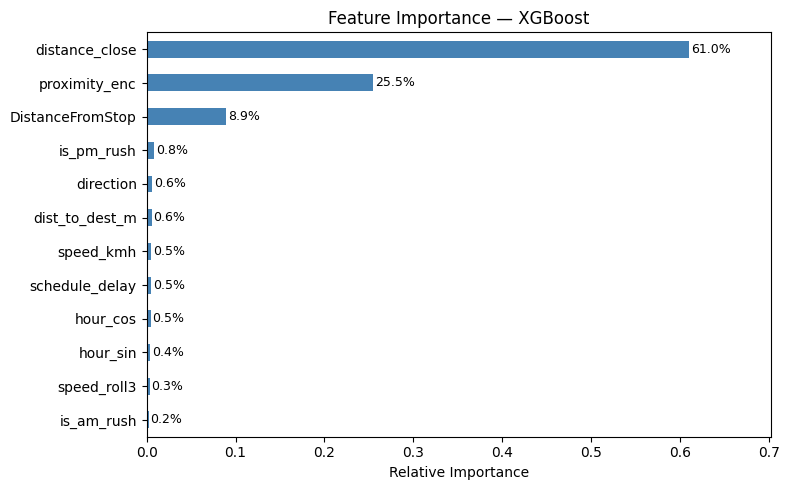

Gráfico guardado como 'feature_importance_xgboost_combined.png'


In [17]:
# ── CELDA 21: NUEVA — feature importance (para la tesis) ─────────────────────
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Relative Importance')
ax.set_title('Feature Importance — XGBoost')
ax.set_xlim(0, importances.max() * 1.15)

# Etiquetas con el porcentaje en cada barra
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_xgboost_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'feature_importance_xgboost_combined.png'")

In [18]:
# ── CELDA 22: MODIFICADA XGBoost — guardar modelo ────────────────────────────
import joblib, pickle

model_filename    = 'xgb_model_eta_final.pkl'
features_filename = 'xgb_features_eta_final.pkl'

joblib.dump(rf_model, model_filename)

meta = {
    'features':    features,
    'best_params': search.best_params_,
    'mae_cv':      -search.best_score_,
    'model_type':  'XGBoost',
}
with open(features_filename, 'wb') as f:
    pickle.dump(meta, f)

print(f"✓ Modelo guardado:   '{model_filename}'")
print(f"✓ Metadata guardada: '{features_filename}'")
print(f"\nFeatures ({len(features)}): {features}")
print(f"Best params: {search.best_params_}")


✓ Modelo guardado:   'xgb_model_eta_final.pkl'
✓ Metadata guardada: 'xgb_features_eta_final.pkl'

Features (12): ['DistanceFromStop', 'dist_to_dest_m', 'distance_close', 'schedule_delay', 'speed_kmh', 'speed_roll3', 'direction', 'hour_sin', 'hour_cos', 'is_am_rush', 'is_pm_rush', 'proximity_enc']
Best params: {'colsample_bytree': np.float64(0.9977829850443283), 'gamma': np.float64(0.08796262633867269), 'learning_rate': np.float64(0.03397657999541459), 'max_depth': 9, 'min_child_weight': 5, 'n_estimators': 703, 'reg_alpha': 1.0, 'reg_lambda': 10.0, 'subsample': np.float64(0.8630451569201374)}
